In [2]:
import re, math
from datetime import datetime
from typing import Optional, Tuple, Dict, Any, List

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(42)
pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 140)

try:
    from IPython.display import display
except Exception:
    display = print

def sec(title: str):
    print("\n" + "="*110)
    print(title)
    print("="*110)

def snap(df: pd.DataFrame, name: str, n=3):
    print(f"\n[{name}] shape={df.shape}")
    if "bucket_start" in df.columns and len(df):
        print(f"[{name}] range: {df['bucket_start'].min()} -> {df['bucket_start'].max()}")
    display(df.head(n))
    display(df.tail(n))

def na_rate(df: pd.DataFrame, cols: List[str]) -> pd.DataFrame:
    rows = []
    for c in cols:
        if c in df.columns:
            rows.append({"col": c, "na_rate": float(df[c].isna().mean())})
        else:
            rows.append({"col": c, "na_rate": None})
    return pd.DataFrame(rows)

In [3]:
DT_FORMAT = "%d/%b/%Y:%H:%M:%S %z"

LOG_RE = re.compile(
    r'^(?P<host>\S+)\s+\S+\s+\S+\s+\[(?P<ts>[^\]]+)\]\s+'
    r'"(?P<request>[^"]*)"\s+(?P<status>\d{3})\s+(?P<bytes>\S+)\s*$'
)
REQ_RE = re.compile(r'^(?P<method>[A-Z]+)\s+(?P<url>\S+)\s+(?P<version>HTTP/\d\.\d)$')

Parsed = Tuple[pd.Timestamp, str, str, str, str, Optional[int], Optional[int], int]

def _parse_line(line: str) -> Optional[Parsed]:
    m = LOG_RE.match(line)
    if not m:
        return None

    host = m.group("host")
    ts_raw = m.group("ts")
    req_raw = m.group("request")
    status_raw = m.group("status")
    bytes_raw = m.group("bytes")

    try:
        dt = pd.Timestamp(datetime.strptime(ts_raw, DT_FORMAT))
    except Exception:
        dt = pd.NaT

    method = url = version = "UNKNOWN"
    rm = REQ_RE.match(req_raw.strip())
    if rm:
        method, url, version = rm.group("method"), rm.group("url"), rm.group("version")

    try:
        status = int(status_raw)
    except Exception:
        status = pd.NA

    if bytes_raw in ("-", ""):
        bval, miss = pd.NA, 1
    else:
        try:
            bval, miss = int(bytes_raw), 0
        except Exception:
            bval, miss = pd.NA, 1

    return (dt, host, method, url, version, status, bval, miss)

def _normalize_raw(df: pd.DataFrame) -> pd.DataFrame:
    df["datetime"] = pd.to_datetime(df["datetime"], errors="coerce")
    df["status"] = pd.to_numeric(df["status"], errors="coerce").astype("Int16")
    df["bytes"] = pd.to_numeric(df["bytes"], errors="coerce").astype("Int64")
    df["bytes_missing_flag"] = pd.to_numeric(df["bytes_missing_flag"], errors="coerce").astype("Int8")
    return df

def parse_file_streaming(path: str, chunk_lines: int = 300_000) -> pd.DataFrame:
    parts, buf = [], []
    with open(path, "r", errors="replace") as f:
        for line in f:
            ev = _parse_line(line.rstrip("\n"))
            if ev is None:
                continue
            buf.append(ev)

            if len(buf) >= chunk_lines:
                df = pd.DataFrame(buf, columns=[
                    "datetime","host","method","url","version","status","bytes","bytes_missing_flag"
                ])
                parts.append(_normalize_raw(df))
                buf = []

    if buf:
        df = pd.DataFrame(buf, columns=[
            "datetime","host","method","url","version","status","bytes","bytes_missing_flag"
        ])
        parts.append(_normalize_raw(df))

    if not parts:
        return pd.DataFrame(columns=[
            "datetime","host","method","url","version","status","bytes","bytes_missing_flag"
        ])

    return pd.concat(parts, ignore_index=True)

In [4]:
sec("STEP 1 — PARSE RAW LOGS")

# Local config (only here)
TRAIN_LOG_PATH = "../data/raw/train.txt"
TEST_LOG_PATH  = "../data/raw/test.txt"
CHUNK_SIZE_LINES = 300_000

raw_train = parse_file_streaming(TRAIN_LOG_PATH, chunk_lines=CHUNK_SIZE_LINES)
raw_test  = parse_file_streaming(TEST_LOG_PATH,  chunk_lines=CHUNK_SIZE_LINES)

print("raw_train:", raw_train.shape, "| raw_test:", raw_test.shape)
display(raw_train.head(3))
display(raw_test.head(3))

def raw_report(df: pd.DataFrame, name: str) -> Dict[str, Any]:
    t = pd.to_datetime(df["datetime"], errors="coerce")
    st = pd.to_numeric(df["status"], errors="coerce")
    by = pd.to_numeric(df["bytes"], errors="coerce")
    return {
        "split": name,
        "rows": int(len(df)),
        "time_min": str(t.min()),
        "time_max": str(t.max()),
        "datetime_na_rate": float(t.isna().mean()),
        "bytes_na_rate": float(by.isna().mean()),
        "bytes_missing_flag_rate": float(pd.to_numeric(df["bytes_missing_flag"], errors="coerce").fillna(0).mean()),
        "status_na_rate": float(st.isna().mean()),
        "rate_4xx": float(st.between(400,499).mean(skipna=True)),
        "rate_5xx": float(st.between(500,599).mean(skipna=True)),
        "unique_hosts": int(df["host"].nunique()),
        "unique_urls": int(df["url"].nunique()),
    }

display(pd.DataFrame([raw_report(raw_train,"train"), raw_report(raw_test,"test")]))

sec("RAW — TOP 10 STATUS + TOP 10 URL (sample if huge)")
print("Train status top10:"); display(raw_train["status"].value_counts(dropna=False).head(10))

SAMPLE_N = 300_000
train_urls = raw_train["url"] if len(raw_train) <= SAMPLE_N else raw_train["url"].sample(SAMPLE_N, random_state=42)
test_urls  = raw_test["url"]  if len(raw_test)  <= SAMPLE_N else raw_test["url"].sample(SAMPLE_N, random_state=42)
print("Train url top10:"); display(train_urls.value_counts(dropna=False).head(10))


STEP 1 — PARSE RAW LOGS
raw_train: (2934932, 8) | raw_test: (526648, 8)


,datetime,host,method,url,version,status,bytes,bytes_missing_flag
0,1995-07-01 00:00:01-04:00,199.72.81.55,GET,/history/apollo/,HTTP/1.0,200,6245,0
1,1995-07-01 00:00:06-04:00,unicomp6.unicomp.net,GET,/shuttle/countdown/,HTTP/1.0,200,3985,0
2,1995-07-01 00:00:09-04:00,199.120.110.21,GET,/shuttle/missions/sts-73/mission-sts-73.html,HTTP/1.0,200,4085,0


,datetime,host,method,url,version,status,bytes,bytes_missing_flag
0,1995-08-23 00:00:00-04:00,ix-mia1-02.ix.netcom.com,GET,/ksc.html,HTTP/1.0,200,7087,0
1,1995-08-23 00:00:05-04:00,internet-gw.watson.ibm.com,GET,/history/apollo/pad-abort-test-2/pad-abort-tes...,HTTP/1.0,200,1292,0
2,1995-08-23 00:00:06-04:00,ix-mia1-02.ix.netcom.com,GET,/images/ksclogo-medium.gif,HTTP/1.0,200,5866,0


,split,rows,time_min,time_max,datetime_na_rate,bytes_na_rate,bytes_missing_flag_rate,status_na_rate,rate_4xx,rate_5xx,unique_hosts,unique_urls
0,train,2934932,1995-07-01 00:00:01-04:00,1995-08-22 23:59:59-04:00,0.0,0.009708,0.009708,0.0,0.005844,0.000032,121246,28366
1,test,526648,1995-08-23 00:00:00-04:00,1995-08-31 23:59:53-04:00,0.0,0.010217,0.010217,0.0,0.007515,0.000021,28976,8899



RAW — TOP 10 STATUS + TOP 10 URL (sample if huge)
Train status top10:


status
200     2642411
304      212452
302       62822
404       17031
403         111
500          64
501          31
400          10
<NA>          0
Name: count, dtype: Int64

Train url top10:


url
/images/NASA-logosmall.gif                 17360
/images/KSC-logosmall.gif                  14530
/images/USA-logosmall.gif                  10671
/images/WORLD-logosmall.gif                10541
/images/MOSAIC-logosmall.gif               10527
/images/ksclogo-medium.gif                 10166
/ksc.html                                   6939
/images/launch-logo.gif                     6788
/history/apollo/images/apollo-logo1.gif     5988
/shuttle/countdown/                         5661
Name: count, dtype: int64

In [5]:
def agg_ts2(raw: pd.DataFrame, freq: str) -> pd.DataFrame:
    d = raw[["datetime","host","status","bytes"]].copy()
    d["datetime"] = pd.to_datetime(d["datetime"], utc=False, errors="coerce")

    b = d["datetime"].dt.floor(freq)
    st = pd.to_numeric(d["status"], errors="coerce")
    bytes_num = pd.to_numeric(d["bytes"], errors="coerce")

    g = d.assign(bucket_start=b, bytes_num=bytes_num).groupby("bucket_start", sort=True)
    idx = g.size().index

    ts2 = pd.DataFrame({
        "bucket_start": idx,
        "hits": g.size().astype("int64").values,
        "bytes_sum": g["bytes_num"].sum(min_count=1).astype("float64").reindex(idx).values,
        "unique_hosts": g["host"].nunique().astype("int64").reindex(idx).values,
        "err_4xx": st.between(400,499).groupby(b).sum().astype("int64").reindex(idx, fill_value=0).values,
        "err_5xx": st.between(500,599).groupby(b).sum().astype("int64").reindex(idx, fill_value=0).values,
    }).sort_values("bucket_start").reset_index(drop=True)

    ts2["avg_bytes_per_req"] = np.where(ts2["hits"] > 0, ts2["bytes_sum"]/ts2["hits"], 0.0)
    ts2["error_rate"] = np.where(ts2["hits"] > 0, (ts2["err_4xx"]+ts2["err_5xx"])/ts2["hits"], 0.0)
    return ts2

def to_ts3(
    ts2: pd.DataFrame,
    freq: str,
    gap_storm_start: pd.Timestamp,
    gap_storm_end: pd.Timestamp,
    unknown_gap_min_hours: int = 12,
    fill_cols=None
) -> pd.DataFrame:
    if fill_cols is None:
        fill_cols = ["hits","bytes_sum","avg_bytes_per_req","err_4xx","err_5xx","error_rate","unique_hosts"]

    if ts2.empty:
        return pd.DataFrame(columns=["bucket_start"] + fill_cols + ["is_missing_bucket","is_gap_storm","is_gap_unknown","is_gap"])

    s, e = ts2["bucket_start"].min(), ts2["bucket_start"].max()
    out = pd.DataFrame({"bucket_start": pd.date_range(s, e, freq=freq, tz=s.tz)})
    out = out.merge(ts2, on="bucket_start", how="left")

    out["is_missing_bucket"] = out["hits"].isna().astype("int8")

    ss = pd.to_datetime(gap_storm_start).floor(freq)
    ee = pd.to_datetime(gap_storm_end).floor(freq)
    out["is_gap_storm"] = ((out["bucket_start"] >= ss) & (out["bucket_start"] < ee)).astype("int8")

    is_m = out["is_missing_bucket"].astype(bool)
    run_id = (is_m != is_m.shift()).cumsum()
    step_min = pd.Timedelta(freq).total_seconds() / 60.0
    min_len = int((unknown_gap_min_hours * 60) / step_min)
    out["is_gap_unknown"] = (is_m & (is_m.groupby(run_id).transform("sum") >= min_len)).astype("int8")

    out["is_gap"] = ((out["is_gap_storm"]==1) | (out["is_gap_unknown"]==1)).astype("int8")

    for c in fill_cols:
        out.loc[(out["is_gap"]==0) & (out[c].isna()), c] = 0
        out.loc[out["is_gap"]==1, c] = np.nan

    return out

def gap_report(df: pd.DataFrame, name: str) -> Dict[str, Any]:
    return {
        "name": name,
        "rows": int(len(df)),
        "time_min": str(df["bucket_start"].min()) if len(df) else None,
        "time_max": str(df["bucket_start"].max()) if len(df) else None,
        "missing_buckets": int(df.get("is_missing_bucket", pd.Series([0])).sum()) if len(df) else 0,
        "gap_total": int(df.get("is_gap", pd.Series([0])).sum()) if len(df) else 0,
        "gap_storm": int(df.get("is_gap_storm", pd.Series([0])).sum()) if len(df) else 0,
        "gap_unknown": int(df.get("is_gap_unknown", pd.Series([0])).sum()) if len(df) else 0,
    }

In [6]:
sec("STEP 2 — BUILD TS3 (DENSE BUCKETS + GAP LABELS)")

# Local config (only here)
TAGS = {"1m":"1min", "5m":"5min", "15m":"15min"}
GAP_STORM_START = pd.Timestamp("1995-08-01 14:52:01-0400")
GAP_STORM_END   = pd.Timestamp("1995-08-03 04:36:13-0400")
UNKNOWN_GAP_MIN_HOURS = 12
FILL_COLS = ["hits","bytes_sum","avg_bytes_per_req","err_4xx","err_5xx","error_rate","unique_hosts"]

ts3: Dict[tuple, pd.DataFrame] = {}

for split_name, raw in [("train", raw_train), ("test", raw_test)]:
    for tag, freq in TAGS.items():
        ts2 = agg_ts2(raw, freq)
        ts3[(split_name, tag)] = to_ts3(
            ts2, freq=freq,
            gap_storm_start=GAP_STORM_START,
            gap_storm_end=GAP_STORM_END,
            unknown_gap_min_hours=UNKNOWN_GAP_MIN_HOURS,
            fill_cols=FILL_COLS
        )

rep = pd.DataFrame([gap_report(ts3[(s,t)], f"{s}_{t}") for s in ["train","test"] for t in TAGS.keys()])
display(rep.sort_values("name").reset_index(drop=True))

sec("TS3 SNAPSHOT (MAIN TAG = 5m)")
MAIN_TAG = "5m"
snap(ts3[("train", MAIN_TAG)], f"ts3_train_{MAIN_TAG}", n=5)


STEP 2 — BUILD TS3 (DENSE BUCKETS + GAP LABELS)


,name,rows,time_min,time_max,missing_buckets,gap_total,gap_storm,gap_unknown
0,test_15m,864,1995-08-23 00:00:00-04:00,1995-08-31 23:45:00-04:00,0,0,0,0
1,test_1m,12960,1995-08-23 00:00:00-04:00,1995-08-31 23:59:00-04:00,32,0,0,0
2,test_5m,2592,1995-08-23 00:00:00-04:00,1995-08-31 23:55:00-04:00,2,0,0,0
3,train_15m,5088,1995-07-01 00:00:00-04:00,1995-08-22 23:45:00-04:00,483,480,151,479
4,train_1m,76320,1995-07-01 00:00:00-04:00,1995-08-22 23:59:00-04:00,7852,7211,2264,7210
5,train_5m,15264,1995-07-01 00:00:00-04:00,1995-08-22 23:55:00-04:00,1490,1442,453,1441



TS3 SNAPSHOT (MAIN TAG = 5m)

[ts3_train_5m] shape=(15264, 12)
[ts3_train_5m] range: 1995-07-01 00:00:00-04:00 -> 1995-08-22 23:55:00-04:00


,bucket_start,hits,bytes_sum,unique_hosts,err_4xx,err_5xx,avg_bytes_per_req,error_rate,is_missing_bucket,is_gap_storm,is_gap_unknown,is_gap
0,1995-07-01 00:00:00-04:00,301.0,5277675.0,60.0,1.0,0.0,17533.803987,0.003322,0,0,0,0
1,1995-07-01 00:05:00-04:00,267.0,5041043.0,53.0,0.0,0.0,18880.310861,0.000000,0,0,0,0
2,1995-07-01 00:10:00-04:00,242.0,6111846.0,55.0,4.0,0.0,25255.561983,0.016529,0,0,0,0
3,1995-07-01 00:15:00-04:00,282.0,4559748.0,55.0,4.0,0.0,16169.319149,0.014184,0,0,0,0
4,1995-07-01 00:20:00-04:00,319.0,7262385.0,66.0,0.0,0.0,22766.097179,0.000000,0,0,0,0


,bucket_start,hits,bytes_sum,unique_hosts,err_4xx,err_5xx,avg_bytes_per_req,error_rate,is_missing_bucket,is_gap_storm,is_gap_unknown,is_gap
15259,1995-08-22 23:35:00-04:00,127.0,2410781.0,26.0,0.0,0.0,18982.527559,0.000000,0,0,0,0
15260,1995-08-22 23:40:00-04:00,119.0,3383983.0,31.0,0.0,0.0,28436.831933,0.000000,0,0,0,0
15261,1995-08-22 23:45:00-04:00,128.0,1618155.0,24.0,0.0,0.0,12641.835938,0.000000,0,0,0,0
15262,1995-08-22 23:50:00-04:00,137.0,1169948.0,25.0,2.0,0.0,8539.766423,0.014599,0,0,0,0
15263,1995-08-22 23:55:00-04:00,138.0,1522436.0,23.0,23.0,0.0,11032.144928,0.166667,0,0,0,0



STEP 3 — EDA QUICK (MAIN TAG)
MAIN_TAG: 5m
train rows: 15264 after gap filter: 13822
test  rows: 2592 after gap filter: 2592


,split,hits_mean,hits_p95,hits_p99,hits_max,bytes_p95,bytes_p99,bytes_max,err_p95,err_max
0,train,212.3377,456.0,612.79,1501.0,9658672.8,14117018.93,23907411.0,0.0237,0.4878
1,test,203.1821,445.0,531.00,655.0,7407254.7,9671692.09,12131703.0,0.0330,0.3519


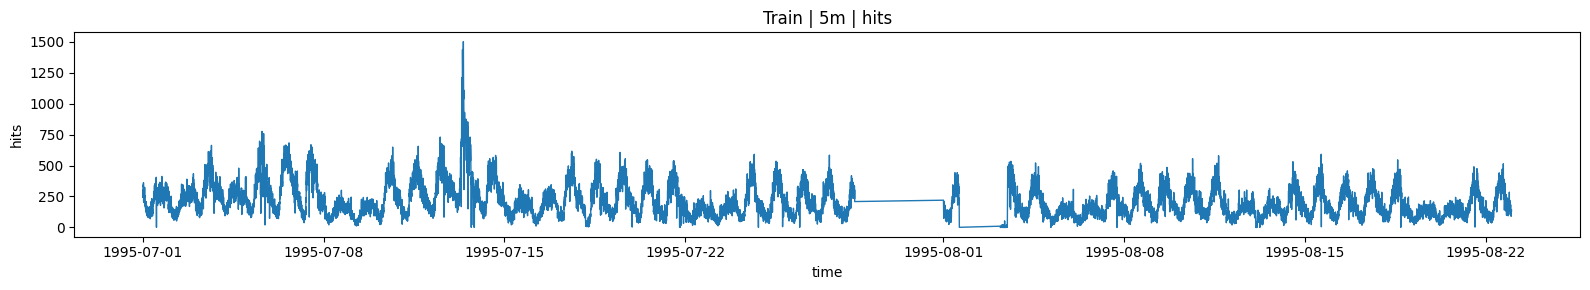

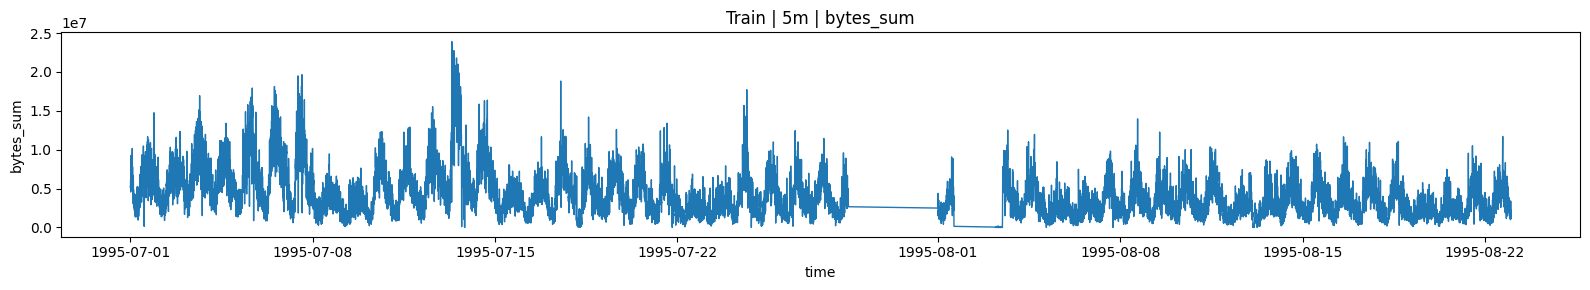

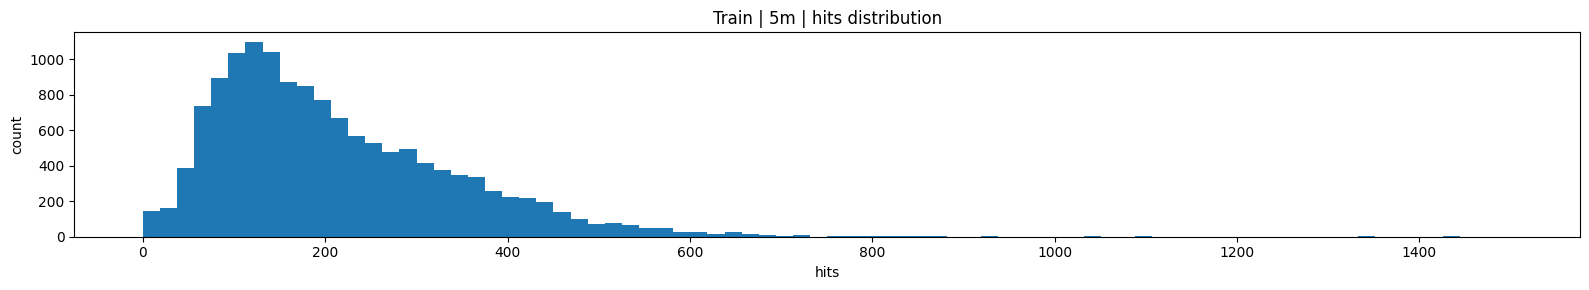

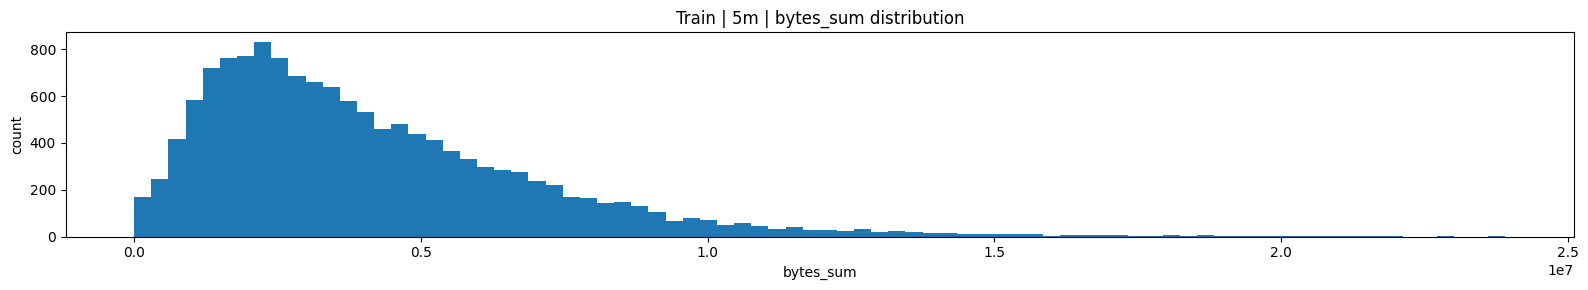

In [7]:
sec("STEP 3 — EDA QUICK (MAIN TAG)")

tr0 = ts3[("train", MAIN_TAG)].copy()
te0 = ts3[("test", MAIN_TAG)].copy()
tr = tr0[tr0["is_gap"]==0].copy()
te = te0[te0["is_gap"]==0].copy()

print("MAIN_TAG:", MAIN_TAG)
print("train rows:", len(tr0), "after gap filter:", len(tr))
print("test  rows:", len(te0), "after gap filter:", len(te))

def pct(s, p):
    return float(np.nanpercentile(pd.to_numeric(s, errors="coerce"), p))

tail_tbl = pd.DataFrame([{
    "split": "train",
    "hits_mean": float(np.nanmean(tr["hits"])),
    "hits_p95": pct(tr["hits"],95),
    "hits_p99": pct(tr["hits"],99),
    "hits_max": float(np.nanmax(tr["hits"])),
    "bytes_p95": pct(tr["bytes_sum"],95),
    "bytes_p99": pct(tr["bytes_sum"],99),
    "bytes_max": float(np.nanmax(tr["bytes_sum"])),
    "err_p95": pct(tr["error_rate"],95),
    "err_max": float(np.nanmax(tr["error_rate"])),
},{
    "split": "test",
    "hits_mean": float(np.nanmean(te["hits"])),
    "hits_p95": pct(te["hits"],95),
    "hits_p99": pct(te["hits"],99),
    "hits_max": float(np.nanmax(te["hits"])),
    "bytes_p95": pct(te["bytes_sum"],95),
    "bytes_p99": pct(te["bytes_sum"],99),
    "bytes_max": float(np.nanmax(te["bytes_sum"])),
    "err_p95": pct(te["error_rate"],95),
    "err_max": float(np.nanmax(te["error_rate"])),
}]).round(4)

display(tail_tbl)

plt.figure(figsize=(16,3))
plt.plot(tr["bucket_start"], tr["hits"], linewidth=1)
plt.title(f"Train | {MAIN_TAG} | hits"); plt.xlabel("time"); plt.ylabel("hits")
plt.tight_layout(); plt.show()

plt.figure(figsize=(16,3))
plt.plot(tr["bucket_start"], tr["bytes_sum"], linewidth=1)
plt.title(f"Train | {MAIN_TAG} | bytes_sum"); plt.xlabel("time"); plt.ylabel("bytes_sum")
plt.tight_layout(); plt.show()

plt.figure(figsize=(16,3))
plt.hist(tr["hits"].dropna(), bins=80)
plt.title(f"Train | {MAIN_TAG} | hits distribution"); plt.xlabel("hits"); plt.ylabel("count")
plt.tight_layout(); plt.show()

plt.figure(figsize=(16,3))
plt.hist(tr["bytes_sum"].dropna(), bins=80)
plt.title(f"Train | {MAIN_TAG} | bytes_sum distribution"); plt.xlabel("bytes_sum"); plt.ylabel("count")
plt.tight_layout(); plt.show()

In [8]:
sec("STEP 4 — FEATURE ENGINEERING (SEGMENT-SAFE, NO LEAKAGE)")

TIME_COL = "bucket_start"
GAP_COL  = "is_gap"
SEG_COL  = "segment_id"

def tag_minutes(tag: str) -> int:
    return {"1m": 1, "5m": 5, "15m": 15}[tag]

def steps_per_day(tag: str) -> int:
    return int(24 * 60 / tag_minutes(tag))

def steps_per_hour(tag: str) -> int:
    return int(60 / tag_minutes(tag))

def resolve_roll_windows(tag: str, roll_windows: List[str]) -> Dict[str, int]:
    sph = steps_per_hour(tag)
    spd = steps_per_day(tag)
    out = {}
    for w in roll_windows:
        if w == "1h": out[w] = 1 * sph
        elif w == "6h": out[w] = 6 * sph
        elif w == "1d": out[w] = 1 * spd
        else: raise ValueError(f"Unsupported roll window: {w}")
    return out

def build_segment_id(df: pd.DataFrame) -> pd.DataFrame:
    d = df.copy()
    is_gap = pd.to_numeric(d[GAP_COL], errors="coerce").fillna(0).astype("int8")
    d[GAP_COL] = is_gap
    is_ok = (is_gap == 0)
    prev_gap = is_gap.shift(1).fillna(1).astype("int8")
    new_seg = (is_ok & (prev_gap == 1)).astype("int8")
    seg = new_seg.cumsum().astype("int32")
    d[SEG_COL] = seg.where(is_ok, other=-1).astype("int32")
    return d

def add_ratio_features(df: pd.DataFrame) -> pd.DataFrame:
    d = df.copy()
    hits = pd.to_numeric(d["hits"], errors="coerce").fillna(0.0).astype(float)
    bsum = pd.to_numeric(d["bytes_sum"], errors="coerce").fillna(0.0).astype(float)
    d["avg_bytes_per_req"] = bsum / np.maximum(hits, 1.0)
    return d

def create_time_features(df: pd.DataFrame, tag: str, ref_time: pd.Timestamp, use_cyclic: bool=True):
    d = df.copy()
    t = pd.to_datetime(d[TIME_COL], errors="coerce")
    ref_time = pd.to_datetime(ref_time)

    d["hour"] = t.dt.hour.astype("int16")
    d["minute"] = t.dt.minute.astype("int16")
    d["dayofweek"] = t.dt.dayofweek.astype("int16")
    d["month"] = t.dt.month.astype("int16")
    d["dayofyear"] = t.dt.dayofyear.astype("int16")
    d["is_weekend"] = (d["dayofweek"] >= 5).astype("int8")

    step_seconds = tag_minutes(tag) * 60
    d["time_idx"] = ((t - ref_time).dt.total_seconds() / step_seconds).astype("int64")

    cols = ["hour","minute","dayofweek","month","dayofyear","is_weekend","time_idx"]
    if use_cyclic:
        hour = d["hour"].astype(float)
        dow  = d["dayofweek"].astype(float)
        d["hour_sin"] = np.sin(2*np.pi*hour/24.0)
        d["hour_cos"] = np.cos(2*np.pi*hour/24.0)
        d["dow_sin"]  = np.sin(2*np.pi*dow/7.0)
        d["dow_cos"]  = np.cos(2*np.pi*dow/7.0)
        cols += ["hour_sin","hour_cos","dow_sin","dow_cos"]
    return d, cols

def add_lags(df: pd.DataFrame, tag: str, target: str, lag_days: List[int]):
    d = df.copy()
    spd = steps_per_day(tag)
    lag_steps = [int(x * spd) for x in lag_days]
    pref = f"{target}_"

    ok = d[d[SEG_COL] >= 0].copy()
    gap = d[d[SEG_COL] < 0].copy()

    def _per_seg(g):
        g = g.sort_values(TIME_COL).copy()
        y = pd.to_numeric(g[target], errors="coerce").astype(float)
        for days, k in zip(lag_days, lag_steps):
            g[f"{pref}lag_{days}d"] = y.shift(k)
        if len(lag_days) >= 2:
            d0, d1 = lag_days[0], lag_days[1]
            g[f"{pref}diff_lag_{d0}d_{d1}d"] = g[f"{pref}lag_{d0}d"] - g[f"{pref}lag_{d1}d"]
        return g

    ok = ok.groupby(SEG_COL, group_keys=False).apply(_per_seg)
    out = pd.concat([ok, gap], ignore_index=True).sort_values(TIME_COL).reset_index(drop=True)

    feat_cols = [f"{pref}lag_{d}d" for d in lag_days]
    if len(lag_days) >= 2:
        d0, d1 = lag_days[0], lag_days[1]
        feat_cols.append(f"{pref}diff_lag_{d0}d_{d1}d")
    return out, feat_cols

def add_rolling(df: pd.DataFrame, tag: str, target: str, roll_windows: List[str], use_std: bool=True):
    d = df.copy()
    roll_map = resolve_roll_windows(tag, roll_windows)
    pref = f"{target}_"

    ok = d[d[SEG_COL] >= 0].copy()
    gap = d[d[SEG_COL] < 0].copy()

    def _per_seg(g):
        g = g.sort_values(TIME_COL).copy()
        y = pd.to_numeric(g[target], errors="coerce").astype(float)
        y_shift = y.shift(1)  # NO LEAKAGE ✅
        for wname, win in roll_map.items():
            g[f"{pref}roll_mean_{wname}"] = y_shift.rolling(win, min_periods=win).mean()
            if use_std:
                g[f"{pref}roll_std_{wname}"] = y_shift.rolling(win, min_periods=win).std()
        return g

    ok = ok.groupby(SEG_COL, group_keys=False).apply(_per_seg)
    out = pd.concat([ok, gap], ignore_index=True).sort_values(TIME_COL).reset_index(drop=True)

    cols = []
    for wname in roll_map.keys():
        cols.append(f"{pref}roll_mean_{wname}")
        if use_std:
            cols.append(f"{pref}roll_std_{wname}")
    return out, cols

def add_labels(df: pd.DataFrame, target: str, label_col: str, horizon_steps: int):
    d = df.copy()
    ok = d[d[SEG_COL] >= 0].copy()
    gap = d[d[SEG_COL] < 0].copy()

    def _per_seg(g):
        g = g.sort_values(TIME_COL).copy()
        g[label_col] = pd.to_numeric(g[target], errors="coerce").astype(float).shift(-horizon_steps)
        return g

    ok = ok.groupby(SEG_COL, group_keys=False).apply(_per_seg)
    return pd.concat([ok, gap], ignore_index=True).sort_values(TIME_COL).reset_index(drop=True)

# Local config (only here)
LAG_DAYS = [1,2,3,4,5,6,7]
ROLL_WINDOWS = ["1h","6h","1d"]
ROLL_USE_STD = True
USE_CYCLIC = True
HORIZON_STEPS = 1

train_feat: Dict[str, pd.DataFrame] = {}
test_feat: Dict[str, pd.DataFrame] = {}
feat_cols: Dict[str, Dict[str, List[str]]] = {}

for tag in TAGS.keys():
    tr = ts3[("train", tag)].copy()
    te = ts3[("test", tag)].copy()

    tr = build_segment_id(tr)
    te = build_segment_id(te)

    tr_clean = tr[tr[GAP_COL] == 0].copy()
    tr_clean = add_ratio_features(tr_clean)

    ref_time = pd.to_datetime(pd.concat([tr[[TIME_COL]], te[[TIME_COL]]], ignore_index=True)[TIME_COL].min())

    tr_clean, time_cols = create_time_features(tr_clean, tag, ref_time, use_cyclic=USE_CYCLIC)

    tr_clean, hits_lag   = add_lags(tr_clean, tag, "hits", LAG_DAYS)
    tr_clean, hits_roll  = add_rolling(tr_clean, tag, "hits", ROLL_WINDOWS, use_std=ROLL_USE_STD)
    tr_clean, bytes_lag  = add_lags(tr_clean, tag, "bytes_sum", LAG_DAYS)
    tr_clean, bytes_roll = add_rolling(tr_clean, tag, "bytes_sum", ROLL_WINDOWS, use_std=ROLL_USE_STD)
    tr_clean, ratio_roll = add_rolling(tr_clean, tag, "avg_bytes_per_req", ROLL_WINDOWS, use_std=ROLL_USE_STD)

    tr_clean = add_labels(tr_clean, "hits", "y_hits_next", HORIZON_STEPS)
    tr_clean = add_labels(tr_clean, "bytes_sum", "y_bytes_sum_next", HORIZON_STEPS)

    hits_feature_cols  = time_cols + hits_lag + hits_roll
    bytes_feature_cols = time_cols + bytes_lag + bytes_roll + ratio_roll + hits_roll

    all_feature_cols = sorted(set(hits_feature_cols + bytes_feature_cols))

    before = len(tr_clean)
    tr_out = tr_clean.dropna(subset=["y_hits_next","y_bytes_sum_next"]).reset_index(drop=True)
    after = len(tr_out)

    # test: history+test then slice back by timestamp key
    hist_and_test = pd.concat([tr, te], ignore_index=True).sort_values(TIME_COL).reset_index(drop=True)
    hist_and_test = build_segment_id(hist_and_test)
    hist_and_test = add_ratio_features(hist_and_test)
    hist_and_test, _ = create_time_features(hist_and_test, tag, ref_time, use_cyclic=USE_CYCLIC)

    hist_and_test, _ = add_lags(hist_and_test, tag, "hits", LAG_DAYS)
    hist_and_test, _ = add_rolling(hist_and_test, tag, "hits", ROLL_WINDOWS, use_std=ROLL_USE_STD)
    hist_and_test, _ = add_lags(hist_and_test, tag, "bytes_sum", LAG_DAYS)
    hist_and_test, _ = add_rolling(hist_and_test, tag, "bytes_sum", ROLL_WINDOWS, use_std=ROLL_USE_STD)
    hist_and_test, _ = add_rolling(hist_and_test, tag, "avg_bytes_per_req", ROLL_WINDOWS, use_std=ROLL_USE_STD)

    def _to_tznaive_dt64(s: pd.Series) -> pd.Series:
        s = pd.to_datetime(s, errors="coerce")
        if getattr(s.dt, "tz", None) is not None:
            s = s.dt.tz_convert(None)
        return s

    hist_and_test[TIME_COL] = _to_tznaive_dt64(hist_and_test[TIME_COL])
    te[TIME_COL]            = _to_tznaive_dt64(te[TIME_COL])

    hist_and_test["_tkey"] = hist_and_test[TIME_COL].view("int64")
    te_key = te[[TIME_COL]].copy()
    te_key["_tkey"] = te_key[TIME_COL].view("int64")

    if hist_and_test["_tkey"].duplicated().any():
        raise ValueError(f"[features] duplicated timestamps in hist_and_test for tag={tag}")

    te_features = (
        te_key.merge(
            hist_and_test.drop(columns=[TIME_COL]),
            on="_tkey",
            how="left",
            validate="one_to_one"
        )
        .sort_values(TIME_COL)
        .reset_index(drop=True)
        .drop(columns=["_tkey"])
    )

    # minimal guard
    for c in ["hits","bytes_sum"]:
        if float(te_features[c].isna().mean()) > 0.01:
            raise ValueError(f"[features] join failed for tag={tag}: {c} NA-rate too high")

    keep_train = [TIME_COL, GAP_COL, SEG_COL, "hits","bytes_sum","avg_bytes_per_req", "y_hits_next","y_bytes_sum_next"] + all_feature_cols
    keep_test  = [TIME_COL, GAP_COL, SEG_COL, "hits","bytes_sum","avg_bytes_per_req"] + all_feature_cols

    train_feat[tag] = tr_out[keep_train].copy()
    test_feat[tag]  = te_features[keep_test].copy()

    feat_cols[tag] = {
        "time_cols": time_cols,
        "hits_feature_cols": [c for c in hits_feature_cols if c not in (TIME_COL, "hits", "y_hits_next")],
        "bytes_feature_cols": [c for c in bytes_feature_cols if c not in (TIME_COL, "bytes_sum", "y_bytes_sum_next")],
        "all_feature_cols": [c for c in all_feature_cols if c != TIME_COL],
        "train_dropped_label_na": int(before - after),
    }

summary = pd.DataFrame([{
    "tag": tag,
    "train_rows": len(train_feat[tag]),
    "test_rows": len(test_feat[tag]),
    "dropped_label_na": feat_cols[tag]["train_dropped_label_na"],
    "n_all_features": len(feat_cols[tag]["all_feature_cols"]),
    "n_hits_feats": len(feat_cols[tag]["hits_feature_cols"]),
    "n_bytes_feats": len(feat_cols[tag]["bytes_feature_cols"]),
} for tag in TAGS.keys()]).sort_values("tag").reset_index(drop=True)

display(summary)

sec("FEATURE SNAPSHOT (tag=5m) + NA rates")
tag = "5m"
display(train_feat[tag][[TIME_COL,"hits","bytes_sum","y_hits_next","y_bytes_sum_next"]].head(5))
display(na_rate(train_feat[tag], ["y_hits_next","y_bytes_sum_next"] + feat_cols[tag]["hits_feature_cols"][:10]).head(15))


STEP 4 — FEATURE ENGINEERING (SEGMENT-SAFE, NO LEAKAGE)


,tag,train_rows,test_rows,dropped_label_na,n_all_features,n_hits_feats,n_bytes_feats
0,15m,4605,864,3,45,25,37
1,1m,69106,12960,3,45,25,37
2,5m,13819,2592,3,45,25,37



FEATURE SNAPSHOT (tag=5m) + NA rates


,bucket_start,hits,bytes_sum,y_hits_next,y_bytes_sum_next
0,1995-07-01 00:00:00-04:00,301.0,5277675.0,267.0,5041043.0
1,1995-07-01 00:05:00-04:00,267.0,5041043.0,242.0,6111846.0
2,1995-07-01 00:10:00-04:00,242.0,6111846.0,282.0,4559748.0
3,1995-07-01 00:15:00-04:00,282.0,4559748.0,319.0,7262385.0
4,1995-07-01 00:20:00-04:00,319.0,7262385.0,344.0,6223927.0


,col,na_rate
0,y_hits_next,0.0
1,y_bytes_sum_next,0.0
2,hour,0.0
3,minute,0.0
4,dayofweek,0.0
5,month,0.0
6,dayofyear,0.0
7,is_weekend,0.0
8,time_idx,0.0
9,hour_sin,0.0


In [9]:
sec("STEP 5 — MODELING (XGB + SEASONAL_NAIVE) + METRICS ON SCREEN")

from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_squared_error, mean_absolute_error
import xgboost as xgb

def mape_threshold(y_true, y_pred, min_y=1.0):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    mask = np.abs(y_true) >= float(min_y)
    if mask.sum() == 0:
        return np.nan
    return float(np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100.0)

def compute_metrics(y_true, y_pred, target: str) -> Dict[str, float]:
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    mse = float(mean_squared_error(y_true, y_pred))
    rmse = float(np.sqrt(mse))
    mae = float(mean_absolute_error(y_true, y_pred))
    mape = mape_threshold(y_true, y_pred, min_y=1024.0 if target=="bytes_sum" else 1.0)
    return {"RMSE": rmse, "MSE": mse, "MAE": mae, "MAPE": mape}

# Local config (only here)
TARGETS = ["hits", "bytes_sum"]
XGB_PARAMS = dict(
    booster="gbtree",
    n_estimators=5000,
    early_stopping_rounds=50,
    objective="reg:squarederror",
    max_depth=6,
    learning_rate=0.05,
    subsample=0.9,
    colsample_bytree=0.9,
    reg_lambda=1.0,
    random_state=42,
)
CV_SPLITS = 5
CV_TEST_DAYS = 2
CV_GAP_STEPS = 1

preds: Dict[tuple, pd.DataFrame] = {}
metrics_long: List[Dict[str, Any]] = []

def train_xgb_one(tag: str, target: str):
    df_tr = train_feat[tag].sort_values(TIME_COL).reset_index(drop=True)
    df_te = test_feat[tag].sort_values(TIME_COL).reset_index(drop=True)

    if target == "hits":
        FEAT_COLS = feat_cols[tag]["hits_feature_cols"]
        LABEL = "y_hits_next"
        TRUE_COL = "hits"
        use_log = False
    else:
        FEAT_COLS = feat_cols[tag]["bytes_feature_cols"]
        LABEL = "y_bytes_sum_next"
        TRUE_COL = "bytes_sum"
        use_log = True

    FEAT_COLS = [c for c in FEAT_COLS if c not in (TIME_COL, TRUE_COL, LABEL)]
    freq_min = tag_minutes(tag)

    test_size = int(CV_TEST_DAYS * 24 * 60 / freq_min)
    gap = int(CV_GAP_STEPS)
    n = len(df_tr)
    max_splits = (n - gap) // test_size - 1
    n_splits_eff = int(min(CV_SPLITS, max(0, max_splits)))

    cv_metrics = []
    if n_splits_eff >= 2:
        tss = TimeSeriesSplit(n_splits=n_splits_eff, test_size=test_size, gap=gap)
        for fold, (tr_idx, va_idx) in enumerate(tss.split(df_tr), start=1):
            trp = df_tr.iloc[tr_idx]
            vap = df_tr.iloc[va_idx]

            X_tr, X_va = trp[FEAT_COLS], vap[FEAT_COLS]
            y_tr = trp[LABEL].astype(float).values
            y_va = vap[LABEL].astype(float).values

            y_tr_fit = np.log1p(np.maximum(y_tr, 0.0)) if use_log else y_tr
            y_va_fit = np.log1p(np.maximum(y_va, 0.0)) if use_log else y_va

            reg = xgb.XGBRegressor(**XGB_PARAMS)
            reg.fit(X_tr, y_tr_fit, eval_set=[(X_va, y_va_fit)], verbose=False)

            pred_fit = reg.predict(X_va)
            pred = np.expm1(pred_fit) if use_log else pred_fit
            pred = np.maximum(pred, 0.0)
            cv_metrics.append(compute_metrics(y_va, pred, target))

    cv_mean = {k: float(np.mean([m[k] for m in cv_metrics])) if cv_metrics else np.nan
               for k in ["RMSE","MSE","MAE","MAPE"]}

    # train full (no early stop)
    final_params = {k:v for k,v in XGB_PARAMS.items() if k != "early_stopping_rounds"}
    model = xgb.XGBRegressor(**final_params)

    y_all = df_tr[LABEL].astype(float).values
    y_fit = np.log1p(np.maximum(y_all, 0.0)) if use_log else y_all
    model.fit(df_tr[FEAT_COLS], y_fit, eval_set=[(df_tr[FEAT_COLS], y_fit)], verbose=False)

    # test 1-step evaluation (t -> t+1)
    df = df_te[[TIME_COL, TRUE_COL] + FEAT_COLS].copy()
    df = df.loc[:, ~df.columns.duplicated()].copy()

    df["true_next"] = pd.to_numeric(df[TRUE_COL], errors="coerce").astype(float).shift(-1)
    eval_df = df[df["true_next"].notna()].copy()

    if len(eval_df) == 0:
        out = df[[TIME_COL, TRUE_COL, "true_next"]].head(0).copy()
        out["pred"] = np.nan
        test_m = {"RMSE": np.nan, "MSE": np.nan, "MAE": np.nan, "MAPE": np.nan}
        return out, cv_mean, test_m

    pred_fit = model.predict(eval_df[FEAT_COLS])
    pred = np.expm1(pred_fit) if use_log else pred_fit
    eval_df["pred"] = np.maximum(pred, 0.0)

    test_m = compute_metrics(eval_df["true_next"].values, eval_df["pred"].values, target)
    out = eval_df[[TIME_COL, TRUE_COL, "true_next", "pred"]].copy()
    return out, cv_mean, test_m

def seasonal_naive_forecast(hist: np.ndarray, season_len: int) -> float:
    hist = np.asarray(hist, dtype=float)
    if len(hist) == 0:
        return 0.0
    if len(hist) < season_len:
        return float(hist[-1])
    return float(hist[-season_len])

def train_seasonal_naive_one(tag: str, target: str):
    tr = ts3[("train", tag)].copy()
    te = ts3[("test", tag)].copy()

    tr = tr[pd.to_numeric(tr["is_gap"], errors="coerce").fillna(0).astype(int)==0].copy()
    tr = tr.sort_values(TIME_COL).reset_index(drop=True)
    te = te.sort_values(TIME_COL).reset_index(drop=True)

    te2 = te.copy()
    te2["true_next"] = pd.to_numeric(te2[target], errors="coerce").astype(float).shift(-1)
    eval_df = te2[te2["true_next"].notna()].copy().reset_index(drop=True)

    if len(eval_df) == 0:
        out = te2[[TIME_COL, target, "true_next"]].head(0).copy()
        out["pred"] = np.nan
        test_m = {"RMSE": np.nan, "MSE": np.nan, "MAE": np.nan, "MAPE": np.nan}
        return out, test_m

    hist = pd.to_numeric(tr[target], errors="coerce").astype(float).fillna(0.0).values.tolist()
    season_len = steps_per_day(tag)

    preds_list = []
    for i in range(len(eval_df)):
        y_t = float(pd.to_numeric(te.iloc[i][target], errors="coerce"))
        if np.isnan(y_t) or np.isinf(y_t):
            y_t = 0.0
        hist.append(y_t)
        p = seasonal_naive_forecast(np.asarray(hist), season_len=season_len)
        preds_list.append(max(0.0, p))

    eval_df["pred"] = np.asarray(preds_list, dtype=float)
    test_m = compute_metrics(eval_df["true_next"].values, eval_df["pred"].values, target)
    out = eval_df[[TIME_COL, target, "true_next", "pred"]].copy()
    return out, test_m

# Run models with printed progress
for target in TARGETS:
    for tag in TAGS.keys():
        print(f"\n--- XGB | target={target} | tag={tag} ---")
        out_xgb, cv_mean, test_m = train_xgb_one(tag, target)
        preds[("xgb", target, tag)] = out_xgb

        print("CV mean:", {k: (None if np.isnan(v) else round(v,4)) for k,v in cv_mean.items()})
        print("TEST   :", {k: (None if np.isnan(v) else round(v,4)) for k,v in test_m.items()})
        display(out_xgb.head(5))

        for split, mm in [("cv_mean", cv_mean), ("test", test_m)]:
            for metric_name, v in mm.items():
                metrics_long.append({
                    "model":"xgb","target":target,"window":tag,"split":split,"metric":metric_name,"value":float(v) if v is not None else np.nan
                })

        print(f"\n--- SeasonalNaive | target={target} | tag={tag} ---")
        out_sn, test_m2 = train_seasonal_naive_one(tag, target)
        preds[("seasonal_naive", target, tag)] = out_sn
        print("TEST   :", {k: (None if np.isnan(v) else round(v,4)) for k,v in test_m2.items()})
        display(out_sn.head(5))

        for metric_name, v in test_m2.items():
            metrics_long.append({
                "model":"seasonal_naive","target":target,"window":tag,"split":"test","metric":metric_name,"value":float(v) if v is not None else np.nan
            })

sec("METRICS (LONG) — DISPLAY")
metrics_df = pd.DataFrame(metrics_long)
display(metrics_df.sort_values(["target","window","model","split","metric"]).reset_index(drop=True))

sec("BENCHMARK (TEST) — PIVOT")
test_m = metrics_df[metrics_df["split"].astype(str).str.lower().eq("test")].copy()
bench = test_m.pivot_table(
    index=["target","window","metric"],
    columns=["model"],
    values="value",
    aggfunc="first"
).reset_index()
display(bench.sort_values(["target","window","metric"]).reset_index(drop=True))

sec("SAMPLE PREDICTIONS (xgb hits/5m)")
display(preds[("xgb","hits","5m")].head(15))


STEP 5 — MODELING (XGB + SEASONAL_NAIVE) + METRICS ON SCREEN

--- XGB | target=hits | tag=1m ---
CV mean: {'RMSE': 14.0361, 'MSE': 200.2665, 'MAE': 10.7038, 'MAPE': 56.3835}
TEST   : {'RMSE': 21.589, 'MSE': 466.0835, 'MAE': 15.582, 'MAPE': 64.463}


,bucket_start,hits,true_next,pred
0,1995-08-23 04:00:00,41.0,30.0,37.849537
1,1995-08-23 04:01:00,30.0,41.0,35.483719
2,1995-08-23 04:02:00,41.0,64.0,29.996441
3,1995-08-23 04:03:00,64.0,34.0,38.095394
4,1995-08-23 04:04:00,34.0,38.0,37.208595



--- SeasonalNaive | target=hits | tag=1m ---
TEST   : {'RMSE': 24.3447, 'MSE': 592.6643, 'MAE': 18.2067, 'MAPE': 74.1452}


,bucket_start,hits,true_next,pred
0,1995-08-23 00:00:00-04:00,41.0,30.0,49.0
1,1995-08-23 00:01:00-04:00,30.0,41.0,42.0
2,1995-08-23 00:02:00-04:00,41.0,64.0,45.0
3,1995-08-23 00:03:00-04:00,64.0,34.0,51.0
4,1995-08-23 00:04:00-04:00,34.0,38.0,45.0



--- XGB | target=hits | tag=5m ---
CV mean: {'RMSE': 47.3839, 'MSE': 2279.5724, 'MAE': 35.257, 'MAPE': 60.0734}
TEST   : {'RMSE': 70.9756, 'MSE': 5037.5387, 'MAE': 52.6092, 'MAPE': 38.355}


...

,model,target,window,split,metric,value
0,seasonal_naive,bytes_sum,15m,test,MAE,3.684467e+06
1,seasonal_naive,bytes_sum,15m,test,MAPE,4.871902e+01
2,seasonal_naive,bytes_sum,15m,test,MSE,2.444569e+13
3,seasonal_naive,bytes_sum,15m,test,RMSE,4.944259e+06
4,xgb,bytes_sum,15m,cv_mean,MAE,2.241636e+06
...,...,...,...,...,...,...
67,xgb,hits,5m,cv_mean,RMSE,4.738390e+01
68,xgb,hits,5m,test,MAE,5.260917e+01
69,xgb,hits,5m,test,MAPE,3.835503e+01
70,xgb,hits,5m,test,MSE,5.037539e+03



BENCHMARK (TEST) — PIVOT


model,target,window,metric,seasonal_naive,xgb
0,bytes_sum,15m,MAE,3.684467e+06,2.825507e+06
1,bytes_sum,15m,MAPE,4.871902e+01,3.180725e+01
2,bytes_sum,15m,MSE,2.444569e+13,1.509453e+13
3,bytes_sum,15m,RMSE,4.944259e+06,3.885168e+06
4,bytes_sum,1m,MAE,4.815762e+05,4.632519e+05
5,bytes_sum,1m,MAPE,1.823394e+02,8.817261e+01
6,bytes_sum,1m,MSE,4.666336e+11,4.895316e+11
7,bytes_sum,1m,RMSE,6.831059e+05,6.996653e+05
8,bytes_sum,5m,MAE,1.546936e+06,1.315083e+06
9,bytes_sum,5m,MAPE,6.910251e+01,4.337299e+01



SAMPLE PREDICTIONS (xgb hits/5m)


,bucket_start,hits,true_next,pred
0,1995-08-23 04:00:00,210.0,125.0,137.614120
1,1995-08-23 04:05:00,125.0,108.0,117.959793
2,1995-08-23 04:10:00,108.0,173.0,102.889198
3,1995-08-23 04:15:00,173.0,130.0,115.807953
4,1995-08-23 04:20:00,130.0,110.0,125.330765
5,1995-08-23 04:25:00,110.0,98.0,94.366440
6,1995-08-23 04:30:00,98.0,113.0,101.907677
7,1995-08-23 04:35:00,113.0,102.0,96.784386
8,1995-08-23 04:40:00,102.0,122.0,107.485733
9,1995-08-23 04:45:00,122.0,119.0,122.751907



STEP 6 — AUTOSCALING SIMULATION (ON-SCREEN KPI + PLOTS)
Case rows: 2544 | range: 1995-08-23 04:00:00 -> 1995-08-31 23:55:00


,timestamp,y_true,y_pred
0,1995-08-23 04:00:00,210.0,137.614120
1,1995-08-23 04:05:00,125.0,117.959793
2,1995-08-23 04:10:00,108.0,102.889198
3,1995-08-23 04:15:00,173.0,115.807953
4,1995-08-23 04:20:00,130.0,125.330765


Static baseline instances (p95 train-style): 5

AUTOSCALING KPI SUMMARY (STATIC vs PREDICTIVE)


,policy_mode,estimated_total_cost,total_server_hours,avg_instances,peak_instances,sla_violation_rate,slo_violation_rate,total_under_provision,max_under_provision,num_scale_events,events_per_hour,num_points
0,static,53.000000,1060.000000,5.000000,5,0.020440,0.0,2425.0,155.0,0,0.000000,2544
1,predictive,33.720833,674.416667,3.181211,15,0.083333,0.0,10132.0,204.0,91,0.429245,2544



Saving = 19.2792 USD (36.38%)
Events (predictive): 91

SCALING EVENTS (TOP 20)


,timestamp,action,from_instances,to_instances,delta,reason
0,1995-08-23 11:20:00,scale_out,2,3,1,req>inst for 2
1,1995-08-23 12:35:00,scale_out,3,4,1,req>inst for 2
2,1995-08-23 14:50:00,scale_out,4,5,1,req>inst for 2
3,1995-08-23 21:05:00,scale_in,5,4,-1,inst>req*(1+margin) for 4
4,1995-08-23 22:15:00,scale_in,4,3,-1,inst>req*(1+margin) for 4
5,1995-08-24 00:30:00,scale_in,3,2,-1,inst>req*(1+margin) for 4
6,1995-08-24 00:55:00,scale_out,2,3,1,req>inst for 2
7,1995-08-24 03:30:00,scale_in,3,2,-1,inst>req*(1+margin) for 4
8,1995-08-24 12:00:00,scale_out,2,3,1,req>inst for 2
9,1995-08-24 12:30:00,scale_out,3,4,1,req>inst for 2


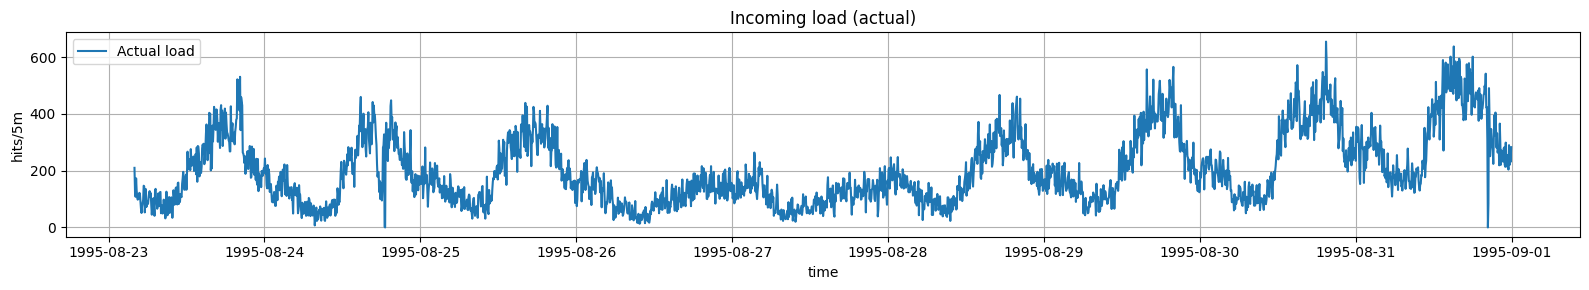

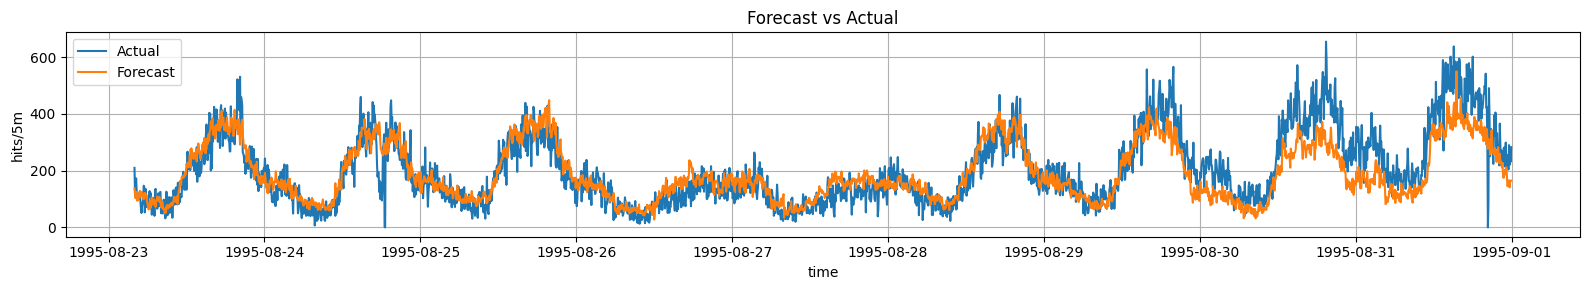

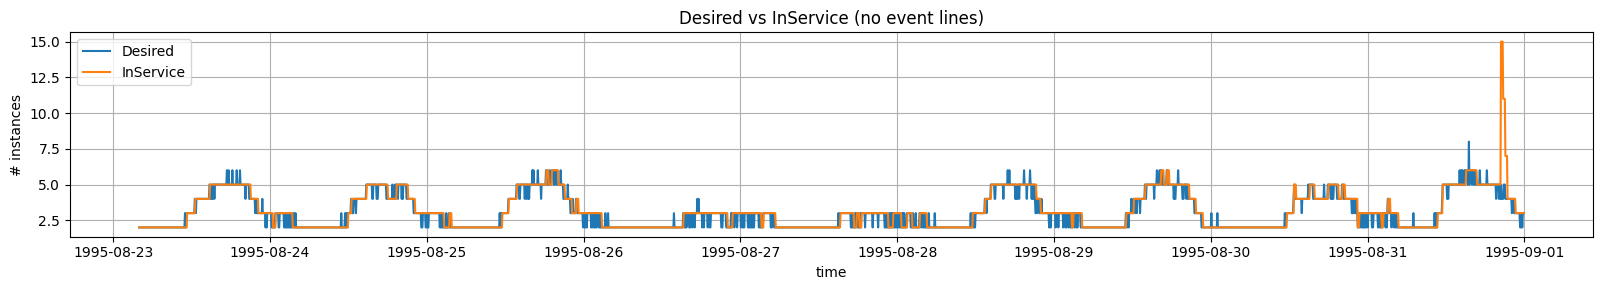

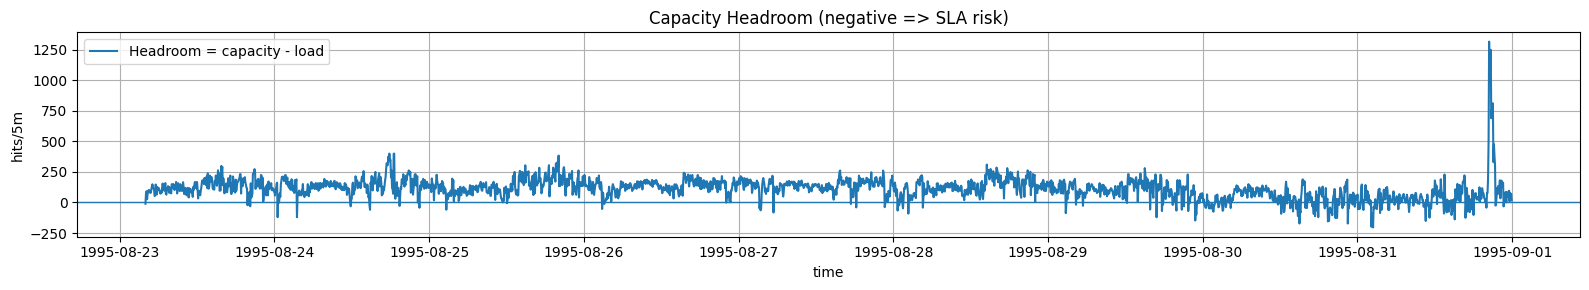

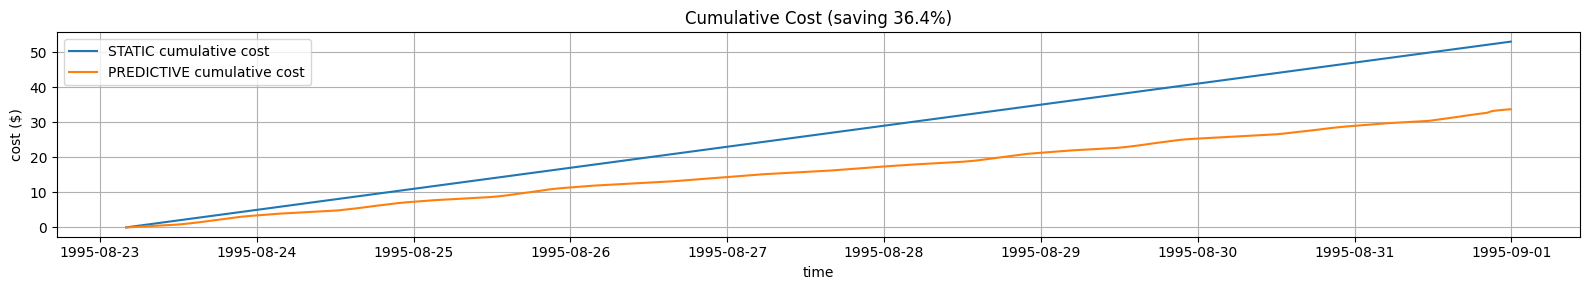

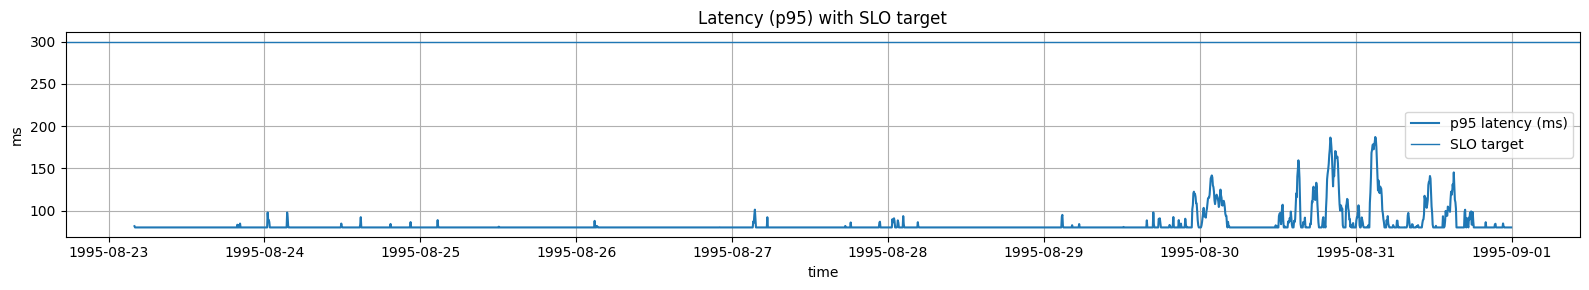

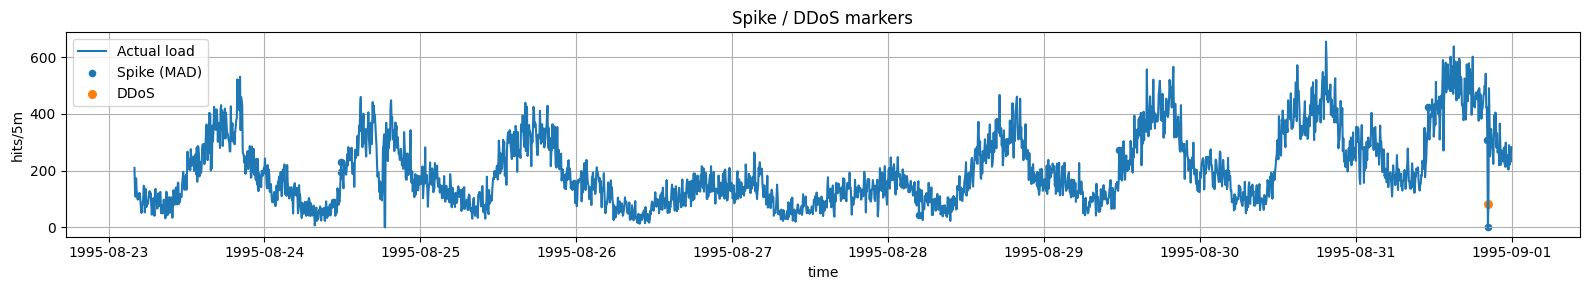

In [10]:
sec("STEP 6 — AUTOSCALING SIMULATION (ON-SCREEN KPI + PLOTS)")

# Local config (only here)
SC = {
    "min_instances": 2,
    "max_instances": 50,
    "cost_per_instance_per_hour": 0.05,
    "window_minutes": {"1m": 1, "5m": 5, "15m": 15},

    "safety_buffer_by_metric": {"hits": 0.30, "bytes_sum": 0.30},

    "capacity_per_instance": {
        ("hits","1m"): 20, ("hits","5m"): 100, ("hits","15m"): 350,
        ("bytes_sum","1m"): 350_000, ("bytes_sum","5m"): 1_200_000, ("bytes_sum","15m"): 3_500_000,
    },

    "max_step_change_by_window": {"1m": 6, "5m": 4, "15m": 15},
    "hysteresis_by_window": {
        "1m": {"high": 2, "low": 6, "in_margin": 0.18},
        "5m": {"high": 2, "low": 4, "in_margin": 0.18},
        "15m":{"high": 1, "low": 2, "in_margin": 0.12},
    },
    "cooldown_minutes": {"base": 15},
    "provisioning_by_window": {
        "1m": {"warmup_windows": 1, "min_uptime_windows": 6},
        "5m": {"warmup_windows": 1, "min_uptime_windows": 4},
        "15m":{"warmup_windows": 0, "min_uptime_windows": 2},
    },

    "slo": {"base_latency_ms": 80.0, "alpha_latency_per_unit_queue": 0.15, "p95_latency_target_ms": 300.0},
    "anomaly": {"enabled": True, "lookback_hours": 2, "mad_k": 6.0, "min_points": 10},
    "ddos_mode": {"enabled": True, "consecutive_windows": 3, "force_step_by_window": {"5m": 10}, "max_instances_during_ddos": 50},
}

LAT_CFG = {
    "base_ms": float(SC["slo"]["base_latency_ms"]),
    "alpha_ms_per_queue_unit": float(SC["slo"]["alpha_latency_per_unit_queue"]),
    "p95_target_ms": float(SC["slo"]["p95_latency_target_ms"]),
    "queue_decay": 0.02,
}

def win_minutes(window: str) -> int:
    return int(SC["window_minutes"][window])

def win_hours(window: str) -> float:
    return win_minutes(window) / 60.0

def clamp_instances(x: int) -> int:
    return max(int(SC["min_instances"]), min(int(SC["max_instances"]), int(x)))

def cap(metric: str, window: str) -> float:
    return float(SC["capacity_per_instance"][(metric, window)])

def buffer(metric: str) -> float:
    return float(SC["safety_buffer_by_metric"].get(metric, 0.2))

def step_limit(window: str) -> int:
    return int(SC["max_step_change_by_window"].get(window, 10))

def required_instances(demand: float, metric: str, window: str) -> int:
    d = max(0.0, float(demand))
    c = max(cap(metric, window), 1e-9)
    need = (d / c) * (1.0 + buffer(metric))
    return clamp_instances(int(math.ceil(need)))

def _apply_step_towards(inst, target, max_step):
    delta = int(target) - int(inst)
    if delta == 0:
        return int(inst)
    step = int(np.sign(delta)) * min(abs(delta), int(max_step))
    return clamp_instances(int(inst) + step)

def mad_anomaly_flags(series: pd.Series, window_pts: int, k: float, min_points: int = 10):
    x = series.astype(float).copy()
    mp = max(1, min(int(window_pts), max(int(min_points), int(window_pts)//2)))
    med = x.rolling(int(window_pts), min_periods=mp).median()
    mad = (x - med).abs().rolling(int(window_pts), min_periods=mp).median()
    score = (x - med).abs() / mad.replace(0, np.nan)
    is_spike = (score > k).fillna(False).astype(int)
    return score.fillna(0.0), is_spike

def ddos_flag(is_spike: pd.Series, consec: int):
    run = is_spike.rolling(consec, min_periods=consec).sum()
    return (run >= consec).fillna(False).astype(int)

def simulate_queue_latency(sim_df: pd.DataFrame, lat_cfg: dict):
    df = sim_df.sort_values("timestamp").reset_index(drop=True).copy()
    q = 0.0
    ql, util, p95, slo = [], [], [], []
    for _, r in df.iterrows():
        load = float(r["y_true"])
        cap_total = float(r["capacity_total"])
        _served = min(load + q, cap_total)
        q = max(0.0, (load + q) - cap_total)
        q = max(0.0, q * (1.0 - float(lat_cfg["queue_decay"])))
        u = 0.0 if cap_total <= 1e-9 else min(2.0, load / cap_total)
        p = float(lat_cfg["base_ms"]) + float(lat_cfg["alpha_ms_per_queue_unit"]) * q
        v = bool(p > float(lat_cfg["p95_target_ms"]))
        ql.append(float(q)); util.append(float(u)); p95.append(float(p)); slo.append(v)
    df["queue_len"] = ql
    df["utilization"] = util
    df["p95_latency_ms"] = p95
    df["slo_violation"] = pd.Series(slo).astype(bool)
    return df

def summarize(sim_df: pd.DataFrame, ev_df: pd.DataFrame) -> dict:
    n = int(len(sim_df))
    total_cost = float(sim_df["cost_step"].sum())
    total_server_hours = float(sim_df["server_hours_step"].sum())
    avg_instances = float(sim_df["instances"].mean())
    peak_instances = int(sim_df["instances"].max())
    sla_violation_rate = float(sim_df["sla_violation"].mean())
    slo_violation_rate = float(sim_df["slo_violation"].mean()) if "slo_violation" in sim_df.columns else np.nan
    total_under = float(sim_df["under_provision"].sum())
    max_under = float(sim_df["under_provision"].max())
    num_scale_events = int(len(ev_df)) if ev_df is not None else 0
    sim_hours = (n * win_minutes(sim_df["window"].iloc[0])) / 60.0
    events_per_hour = float(num_scale_events / max(sim_hours, 1e-9))
    return {
        "policy_mode": str(sim_df["policy_mode"].iloc[0]),
        "estimated_total_cost": total_cost,
        "total_server_hours": total_server_hours,
        "avg_instances": avg_instances,
        "peak_instances": peak_instances,
        "sla_violation_rate": sla_violation_rate,
        "slo_violation_rate": float(slo_violation_rate),
        "total_under_provision": total_under,
        "max_under_provision": max_under,
        "num_scale_events": num_scale_events,
        "events_per_hour": events_per_hour,
        "num_points": n,
    }

# choose scenario from in-memory predictions
metric = "hits"
window = "5m"
model = "xgb"

pred_df = preds[(model, metric, window)].copy()

# build case series (timestamp, y_true, y_pred)
df_case = pd.DataFrame({
    "timestamp": pd.to_datetime(pred_df[TIME_COL], errors="coerce"),
    "y_true": pd.to_numeric(pred_df[metric], errors="coerce").fillna(0.0),
    "y_pred": pd.to_numeric(pred_df["pred"], errors="coerce").fillna(0.0),
}).dropna(subset=["timestamp"]).sort_values("timestamp").reset_index(drop=True)

# Local config: test range (as spec)
TEST_START = pd.Timestamp("1995-08-23 00:00:00")
TEST_END   = pd.Timestamp("1995-09-01 00:00:00")
df_case = df_case[(df_case["timestamp"] >= TEST_START) & (df_case["timestamp"] < TEST_END)].copy().reset_index(drop=True)

print("Case rows:", len(df_case), "| range:", df_case["timestamp"].min(), "->", df_case["timestamp"].max())
display(df_case.head(5))

# STATIC baseline tuned on pre-test slice (no leakage)
TRAIN_END = pd.Timestamp("1995-08-23 00:00:00")
df_train = df_case[df_case["timestamp"] < TRAIN_END].copy()
if df_train.empty:
    df_train = df_case.iloc[: int(len(df_case) * 0.7)].copy()

static_req_train = df_train["y_true"].apply(lambda x: required_instances(x, metric, window))
static_n = clamp_instances(int(np.nanpercentile(static_req_train.values, 95)))
print("Static baseline instances (p95 train-style):", static_n)

def simulate_static(df_case: pd.DataFrame, metric: str, window: str, static_n: int):
    df = df_case.sort_values("timestamp").reset_index(drop=True).copy()
    wh = win_hours(window)
    unit_cost = float(SC["cost_per_instance_per_hour"])
    inst = clamp_instances(static_n)
    rows = []
    for _, r in df.iterrows():
        ts = r["timestamp"]
        y_true = float(r["y_true"])
        y_pred = float(r["y_pred"])
        capacity_total = inst * cap(metric, window)
        headroom = capacity_total - y_true
        under = max(0.0, -headroom)
        over = max(0.0, headroom)
        cost_step = inst * wh * unit_cost
        rows.append({
            "timestamp": ts, "metric": metric, "window": window, "policy_mode": "static",
            "y_true": y_true, "y_pred": y_pred,
            "required_instances": int(required_instances(y_pred, metric, window)),
            "instances": int(inst), "effective_instances": int(inst),
            "capacity_total": float(capacity_total),
            "headroom": float(headroom),
            "under_provision": float(under), "over_provision": float(over),
            "sla_violation": bool(under > 0.0),
            "cost_step": float(cost_step),
            "server_hours_step": float(inst * wh),
        })
    sim_df = pd.DataFrame(rows)
    ev_df = pd.DataFrame(columns=["timestamp","action","from_instances","to_instances","delta","reason"])
    return sim_df, ev_df

def simulate_predictive(df_case: pd.DataFrame, metric: str, window: str):
    df = df_case.sort_values("timestamp").reset_index(drop=True).copy()
    wh = win_hours(window)
    unit_cost = float(SC["cost_per_instance_per_hour"])

    h = SC["hysteresis_by_window"][window]
    k_high = int(h["high"]); k_low = int(h["low"]); in_margin = float(h["in_margin"])
    cooldown_w = int(math.ceil(float(SC["cooldown_minutes"]["base"]) / win_minutes(window)))
    prov = SC["provisioning_by_window"][window]
    warmup_w = int(prov["warmup_windows"]); min_uptime_w = int(prov["min_uptime_windows"])

    # anomaly / ddos precompute (demo)
    anom = SC["anomaly"]
    ddos = SC["ddos_mode"]
    if bool(anom["enabled"]):
        lookback_pts = max(5, int((float(anom["lookback_hours"]) * 60) / win_minutes(window)))
        an_score, is_spike = mad_anomaly_flags(df["y_true"], lookback_pts, float(anom["mad_k"]), int(anom["min_points"]))
        is_ddos = ddos_flag(is_spike, int(ddos["consecutive_windows"])) if bool(ddos["enabled"]) else pd.Series(np.zeros(len(df), dtype=int))
    else:
        an_score = pd.Series(np.zeros(len(df)))
        is_spike = pd.Series(np.zeros(len(df), dtype=int))
        is_ddos  = pd.Series(np.zeros(len(df), dtype=int))

    inst = int(SC["min_instances"])
    above_count = below_count = 0
    cooldown_left = warmup_left = uptime_guard = 0

    rows, events = [], []
    for i, r in df.iterrows():
        ts = r["timestamp"]
        y_true = float(r["y_true"])
        y_pred = float(r["y_pred"])
        req = required_instances(y_pred, metric, window)

        above_count = (above_count + 1) if (req > inst) else 0
        below_count = (below_count + 1) if (inst > req * (1.0 + in_margin)) else 0

        cooldown_left = max(0, cooldown_left - 1)
        warmup_left = max(0, warmup_left - 1)
        uptime_guard = max(0, uptime_guard - 1)

        action, reason = "hold", "hold"
        new_inst = inst

        ddos_on = bool(ddos["enabled"] and int(is_ddos.iloc[i]) == 1)
        if ddos_on:
            force = int(ddos["force_step_by_window"].get(window, step_limit(window)))
            new_inst = min(int(ddos["max_instances_during_ddos"]), inst + max(1, force))
            action, reason = "scale_out", "ddos_mode(force_step)"
        elif cooldown_left == 0:
            if above_count >= k_high:
                new_inst = _apply_step_towards(inst, req, step_limit(window))
                action, reason = "scale_out", f"req>inst for {k_high}"
            elif below_count >= k_low and uptime_guard == 0:
                new_inst = _apply_step_towards(inst, req, step_limit(window))
                action, reason = "scale_in", f"inst>req*(1+margin) for {k_low}"

        if new_inst != inst:
            events.append({
                "timestamp": ts,
                "action": action,
                "from_instances": int(inst),
                "to_instances": int(new_inst),
                "delta": int(new_inst - inst),
                "reason": reason,
            })
            inst = int(new_inst)
            cooldown_left = cooldown_w
            warmup_left = max(warmup_left, warmup_w)
            uptime_guard = max(uptime_guard, min_uptime_w)

        effective_inst = max(0, inst - warmup_left)
        capacity_total = effective_inst * cap(metric, window)

        headroom = capacity_total - y_true
        under = max(0.0, -headroom)
        over = max(0.0, headroom)
        cost_step = inst * wh * unit_cost

        rows.append({
            "timestamp": ts, "metric": metric, "window": window, "policy_mode": "predictive",
            "y_true": y_true, "y_pred": y_pred,
            "required_instances": int(req),
            "instances": int(inst),
            "effective_instances": int(effective_inst),
            "capacity_total": float(capacity_total),
            "headroom": float(headroom),
            "under_provision": float(under), "over_provision": float(over),
            "sla_violation": bool(under > 0.0),
            "cost_step": float(cost_step),
            "server_hours_step": float(inst * wh),
            "anomaly_score": float(an_score.iloc[i]),
            "is_spike": int(is_spike.iloc[i]),
            "is_ddos": int(is_ddos.iloc[i]),
        })

    return pd.DataFrame(rows), pd.DataFrame(events)

sim_static, ev_static = simulate_static(df_case, metric, window, static_n)
sim_pred, ev_pred     = simulate_predictive(df_case, metric, window)

sim_static = simulate_queue_latency(sim_static, LAT_CFG)
sim_pred   = simulate_queue_latency(sim_pred, LAT_CFG)

sum_static = summarize(sim_static, ev_static)
sum_pred   = summarize(sim_pred, ev_pred)
summary_df = pd.DataFrame([sum_static, sum_pred])

saving = sum_static["estimated_total_cost"] - sum_pred["estimated_total_cost"]
saving_pct = saving / max(sum_static["estimated_total_cost"], 1e-9)

sec("AUTOSCALING KPI SUMMARY (STATIC vs PREDICTIVE)")
display(summary_df)
print(f"\nSaving = {saving:.4f} USD ({saving_pct*100:.2f}%)")
print("Events (predictive):", len(ev_pred))

sec("SCALING EVENTS (TOP 20)")
display(ev_pred.head(20))

# Plots
ts = sim_pred["timestamp"]

plt.figure(figsize=(16,3))
plt.plot(ts, sim_pred["y_true"], label="Actual load")
plt.title("Incoming load (actual)"); plt.xlabel("time"); plt.ylabel(f"{metric}/{window}")
plt.grid(True); plt.legend(); plt.tight_layout(); plt.show()

plt.figure(figsize=(16,3))
plt.plot(ts, sim_pred["y_true"], label="Actual")
plt.plot(ts, sim_pred["y_pred"], label="Forecast")
plt.title("Forecast vs Actual"); plt.xlabel("time"); plt.ylabel(f"{metric}/{window}")
plt.grid(True); plt.legend(); plt.tight_layout(); plt.show()

plt.figure(figsize=(16,3))
plt.plot(ts, sim_pred["required_instances"], label="Desired")
plt.plot(ts, sim_pred["instances"], label="InService")
plt.title("Desired vs InService (no event lines)"); plt.xlabel("time"); plt.ylabel("# instances")
plt.grid(True); plt.legend(); plt.tight_layout(); plt.show()

plt.figure(figsize=(16,3))
plt.plot(ts, sim_pred["headroom"], label="Headroom = capacity - load")
plt.axhline(0, linewidth=1)
plt.title("Capacity Headroom (negative => SLA risk)"); plt.xlabel("time"); plt.ylabel(f"{metric}/{window}")
plt.grid(True); plt.legend(); plt.tight_layout(); plt.show()

plt.figure(figsize=(16,3))
plt.plot(sim_static["timestamp"], sim_static["cost_step"].cumsum(), label="STATIC cumulative cost")
plt.plot(sim_pred["timestamp"], sim_pred["cost_step"].cumsum(), label="PREDICTIVE cumulative cost")
plt.title(f"Cumulative Cost (saving {saving_pct*100:.1f}%)"); plt.xlabel("time"); plt.ylabel("cost ($)")
plt.grid(True); plt.legend(); plt.tight_layout(); plt.show()

plt.figure(figsize=(16,3))
plt.plot(ts, sim_pred["p95_latency_ms"], label="p95 latency (ms)")
plt.axhline(LAT_CFG["p95_target_ms"], linewidth=1, label="SLO target")
plt.title("Latency (p95) with SLO target"); plt.xlabel("time"); plt.ylabel("ms")
plt.grid(True); plt.legend(); plt.tight_layout(); plt.show()

plt.figure(figsize=(16,3))
plt.plot(ts, sim_pred["y_true"], label="Actual load")
sp = sim_pred[sim_pred["is_spike"] == 1]
dd = sim_pred[sim_pred["is_ddos"] == 1]
if not sp.empty: plt.scatter(sp["timestamp"], sp["y_true"], s=20, label="Spike (MAD)")
if not dd.empty: plt.scatter(dd["timestamp"], dd["y_true"], s=30, label="DDoS")
plt.title("Spike / DDoS markers"); plt.xlabel("time"); plt.ylabel(f"{metric}/{window}")
plt.grid(True); plt.legend(); plt.tight_layout(); plt.show()